# Ride Demand Prediction — Data Exploration & XGBoost Model

## Overview
This notebook forms the primary data pipeline for predicting hourly ride demand
across Manhattan taxi zones. We are loading, cleaning and aggregate 12 months of NYC Yellow
Taxi trip records (2024), engineer time-series features, and train an XGBoost
regression model as our first and primary demand prediction model.

**Target Variable:** `demand` — number of rides per zone per hour  
**Data Source:** NYC Taxi & Limousine Commission, 2024 Yellow Taxi Trip Records  
**Geographic Scope:** Manhattan only (69 pickup zones)

## 1. Library Imports

We begin by importing the necessary libraries for data manipulation, visualisation,
and model training. XGBoost is a gradient boosting framework widely adopted in
industry and academic literature for structured/tabular data due to its strong
predictive performance and computational efficiency (Chen & Guestrin, 2016).

In [2]:
import sys, os
sys.path.append(os.path.abspath('../ride_demand')) # Accessing Kimon's dataset.py module

import dataset                          # Shared data loader (Kimon's module)
import pandas as pd                     # Data manipulation and aggregation
import numpy as np                      # Numerical operations
import matplotlib.pyplot as plt         # Plotting and visualisation
import seaborn as sns                   # Enhanced statistical visualisation

from xgboost import XGBRegressor        # Primary model — install with: pip install xgboost
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# pretty palette <3
pretty_palette = ['#6c28ff','#fc76f7', "#fab4ff"]

## 2. Data Loading

We load the NYC Yellow Taxi trip records for 2024 using the shared `dataset.py`
module. The full 12-month dataset is used for final model training and evaluation.

Each row in the raw dataset represents a **single taxi trip**, containing
pickup/dropoff timestamps, location IDs, fare amounts, and other trip-level
attributes.

**Note:** The raw dataset contains approximately 41 million rows across all NYC
boroughs for 2024. Loading all 12 months may take several minutes.

In [3]:
# Load all 12 months of 2024 NYC Yellow Taxi data
# Files expected at: ../../data/nyc_taxi_2024-XX.csv
# During development, use month_end=2 to speed up iteration
df = dataset.raw(month_start=1, month_end=12)

# Sanity check: confirm data loaded correctly
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (41169720, 19)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

First 3 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0


## 3. Geographic Filtering — Manhattan Only

The NYC TLC dataset covers all five boroughs. Since our ride-hailing platform is
launching exclusively in **Manhattan**, we use the official TLC Taxi Zone Lookup
table to identify the 69 Manhattan pickup zones.

Filtering to a single borough:
- Reduces noise from other geographic areas
- Ensures predictions are relevant to the operational scope of the business
- Significantly reduces dataset size, improving model training speed

In [4]:
# Load the TLC Taxi Zone Lookup table
# This maps LocationID -> Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island)
zones = pd.read_csv("../../data/taxi_zone_lookup.csv")

print(zones.head())
print("\nBoroughs available:", zones["Borough"].unique())

# Extract only Manhattan zone IDs (69 zones)
manhattan_ids = zones[zones["Borough"] == "Manhattan"]["LocationID"].tolist()
print(f"\nNumber of Manhattan zones: {len(manhattan_ids)}")

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone

Boroughs available: ['EWR' 'Queens' 'Bronx' 'Manhattan' 'Staten Island' 'Brooklyn' 'Unknown'
 nan]

Number of Manhattan zones: 69


## 4. Data Cleaning

Real-world datasets invariably contain erroneous or missing records. We apply the
following cleaning steps to ensure data quality before modelling:

- **Manhattan filter**: Keep only pickups originating within Manhattan's 69 zones
- **Invalid fares**: Remove trips with zero or negative fare amounts — these represent
  data entry errors or non-standard transactions (e.g. cancelled rides)
- **Invalid distances**: Exclude trips with zero or negative trip distances
- **Temporal anomalies**: Remove trips where pickup time occurs *after* dropoff time —
  these are physically impossible and indicate data corruption
- **Missing timestamps**: Drop rows with null pickup datetimes, as the timestamp is
  fundamental to our time-series modelling approach

In [5]:
# Step 1: Filter to Manhattan pickups only
df = df[df["PULocationID"].isin(manhattan_ids)]

# Step 2: Remove invalid fare amounts (zero or negative fares are not meaningful)
df = df[df["fare_amount"] > 0]

# Step 3: Remove invalid trip distances (zero or negative distances indicate bad data)
df = df[df["trip_distance"] > 0]

# Step 4: Remove temporal anomalies (pickup cannot occur after dropoff)
df = df[df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]]

# Step 5: Remove rows with missing pickup timestamps
df = df.dropna(subset=["tpep_pickup_datetime"])

# Confirm cleaning results
print("Shape after cleaning:", df.shape)
print("\nRemaining null values per column:")
print(df.isnull().sum())

Shape after cleaning: (35261412, 19)

Remaining null values per column:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          3249005
trip_distance                  0
RatecodeID               3249005
store_and_fwd_flag       3249005
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     3249005
Airport_fee              3249005
dtype: int64


### Fare-Related Distributions

- Observing `fare_amount`, `total_amount` and `tip` to see any patterns / outliers
- Some fares, tips and total amounts are negative values which are not valid (refunds, cancelled, data errors)
- Heavy right skew on all distributions > many small fares, few huge ones

In [6]:
for col in ["fare_amount", "tip_amount", "total_amount"]:
    print(f"\n--- {col} ---")
    print("min:", df[col].min())
    print("< 0 count:", (df[col] < 0).sum())
    print("NaN count:", df[col].isna().sum())


--- fare_amount ---
min: 0.01
< 0 count: 0
NaN count: 0

--- tip_amount ---
min: 0.0
< 0 count: 0
NaN count: 0

--- total_amount ---
min: 0.0
< 0 count: 0
NaN count: 0


In [7]:
# Step 6: Remove negative fare_amounts, tip_amounts, and total_amounts
df = df[df["fare_amount"] > 0]
df = df[df["total_amount"] > 0]
df = df[df["tip_amount"] >= 0]  # (allow 0 tips = no tip)

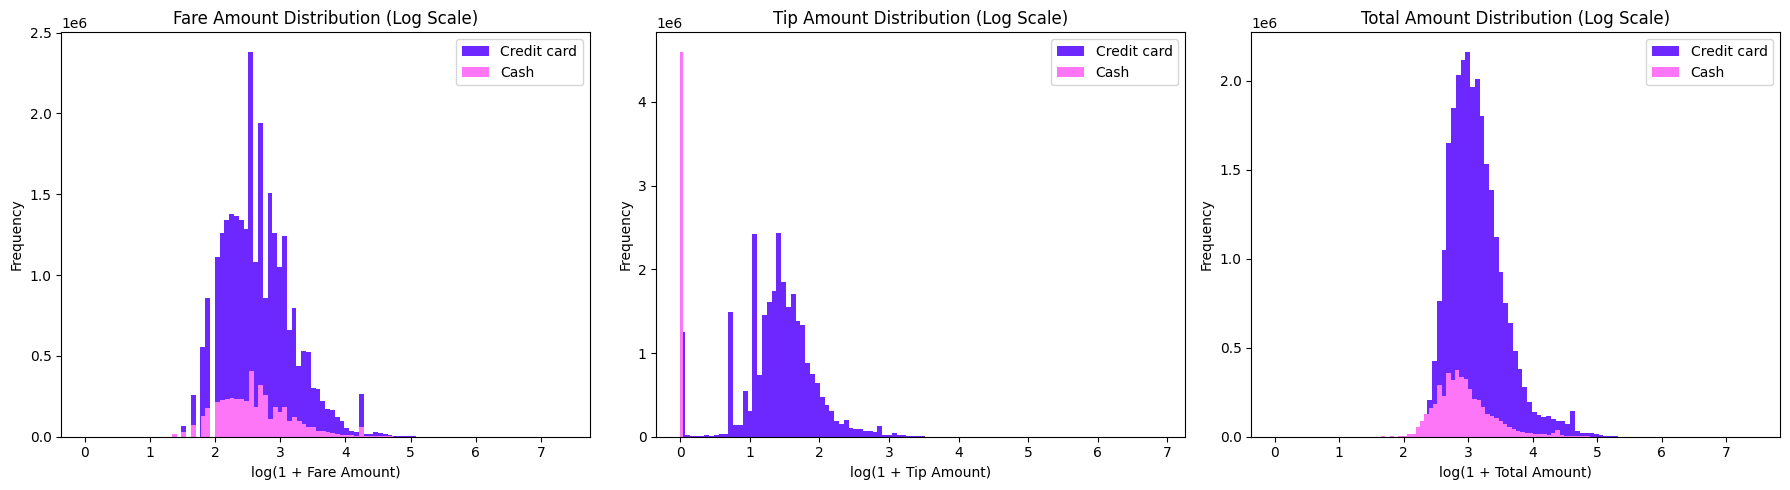

In [8]:
# Taking logs for better visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Masks (computed once)
credit_mask = df["payment_type"] == 1
cash_mask = df["payment_type"] == 2

# Fare_amount distribution
axes[0].hist(np.log1p(df.loc[credit_mask, "fare_amount"]),
             bins=100, label="Credit card", color=pretty_palette[0])
axes[0].hist(np.log1p(df.loc[cash_mask, "fare_amount"]),
             bins=100, label="Cash", color=pretty_palette[1])

# Tip_amount distribution
axes[1].hist(np.log1p(df.loc[credit_mask, "tip_amount"]),
             bins=100, label="Credit card", color=pretty_palette[0])
axes[1].hist(np.log1p(df.loc[cash_mask, "tip_amount"]),
             bins=100, label="Cash", color=pretty_palette[1])

# Total_amount distribution
axes[2].hist(np.log1p(df.loc[credit_mask, "total_amount"]),
             bins=100, label="Credit card", color=pretty_palette[0])
axes[2].hist(np.log1p(df.loc[cash_mask, "total_amount"]),
             bins=100, label="Cash", color=pretty_palette[1])

# Fare_amount formatting
axes[0].set_title("Fare Amount Distribution (Log Scale)")
axes[0].set_xlabel("log(1 + Fare Amount)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Tip_amount formatting
axes[1].set_title("Tip Amount Distribution (Log Scale)")
axes[1].set_xlabel("log(1 + Tip Amount)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Total_amount formatting
axes[2].set_title("Total Amount Distribution (Log Scale)")
axes[2].set_xlabel("log(1 + Total Amount)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.show()

Observations:
- For `fare_amount`, credit card and cash transactions have similar log-transformed distributions, suggesting that choice of payment method is not strongly influenced by fare amount
- We can see (as described in the data dictionary) that `tip_amount` does not include cash tips (all cash tips are 0)
- As a result, `total_amount` which include `fare_amount` and `tip_amount` (and other charges) is more right-skewed for cash payment type trips, potentially introducing bias into the model

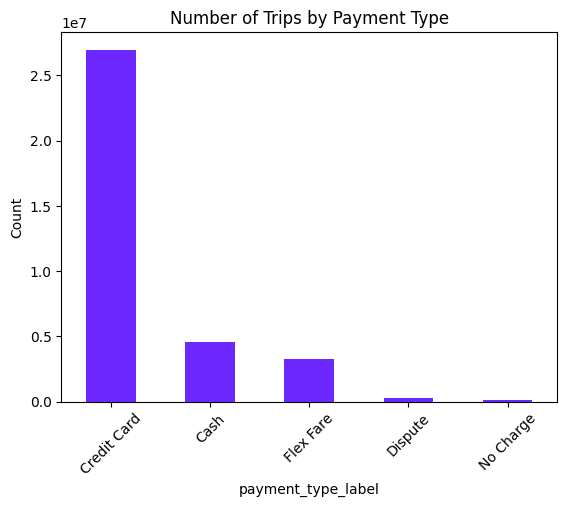

In [9]:
# Payment types -> names (from data dictionary PDF)
payment_map = {
    0: "Flex Fare",
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

df["payment_type_label"] = df["payment_type"].map(payment_map)

df["payment_type_label"].value_counts().plot(kind="bar", color=pretty_palette[0])
plt.title("Number of Trips by Payment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Potential feature: fare_profit

`fare_profit` = `fare_amount` + `tips`

**Why?**
- `fare_amount` represents the time/distance number displayed by the taxi meter
- `total_amount` is the `fare_amount` + any surcharges and tolls + tips
- surcharges and tolls are not pocketed by the driver, they are paid back to eg NYC state
- tips are pocketed by the driver, and should be counted in a profit model

In [10]:
df["fare_profit"] = df["fare_amount"] + df["tip_amount"]

## 5. Temporal Aggregation — From Trip-Level to Hourly Trips

A key design decision in this pipeline is the **aggregation of individual trip
records into hourly demand counts per zone**. This transforms the problem from
a raw transaction log into a structured time-series forecasting task.

**Why aggregate?**
- Each row currently represents one taxi trip — not directly useful for demand
  forecasting
- We need to predict *"how many rides will happen in zone X during hour Y?"*
- Aggregating collapses ~35M rows into ~500K structured observations

**For each (zone, hour) pair we compute:**
- `demand` — count of pickups (demand team's **primary prediction target**)
- `avg_fare` — mean fare amount (fare team's **primary prediction target**)
- `total_profit` — sum of calculated fare profits (fare team)
- `total_revenue` — sum of total amounts (fare team)

This aggregated data is also saved to `data/hourly_aggregated.csv` for use by
the revenue modelling team (Emma & Lucy), avoiding duplication of preprocessing work.

In [ ]:
# Round each pickup timestamp down to the nearest hour
# e.g. 14:37 becomes 14:00 — this is our grouping key
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

# Group by (zone, hour) and aggregate:
# - demand = count of trips (demand-side target variable)
# - avg_fare = mean fare per ride (fare-side target variable)
# - total_profit = total profit in that zone/hour (fare-side additional target variable if needbe)
# we use fare_amount for avg_fare and total_revenue to exclude charges not taken as profit by business (tolls & surcharges)
hourly = df.groupby(["pickup_hour", "PULocationID"]).agg(
    demand        = ("PULocationID", "count"),   # number of rides = demand
    avg_fare      = ("fare_amount", "mean"),      # average fare per ride
    avg_tips      = ("tip_amount", "mean"),       # average tips per ride
    # avg_profit  = ("fare_profit", "mean"),        # average profit per ride
    # total_revenue = ("total_amount", "sum")       # total revenue in zone/hour - FOR ILLUSTRATIVE PURPOSES ONLY
).reset_index()

# Sorting by pickup hour
hourly = hourly.sort_values("pickup_hour")

print("Shape of aggregated data:", hourly.shape)
print("\nSample rows:")
hourly.head(5)

Shape of aggregated data: (507576, 6)

Sample rows:


,pickup_hour,PULocationID,demand,avg_fare,avg_profit,total_revenue
0,2002-12-31 22:00:00,50,1,10.0,13.00,18.00
1,2002-12-31 22:00:00,170,2,19.8,23.61,56.22
2,2002-12-31 22:00:00,237,1,7.9,7.90,11.90
3,2002-12-31 22:00:00,246,1,7.2,7.20,11.20
4,2002-12-31 23:00:00,162,1,45.7,57.53,70.97


## 7. Feature Engineering

Raw datetime objects cannot be directly consumed by machine learning models.
We extract a set of **meaningful temporal features** that capture known patterns
in urban taxi demand:

| Feature | Description | Why it matters |
|---|---|---|
| `hour` | Hour of day (0–23) | Captures rush hour vs quiet periods |
| `day_of_week` | Day of week (0=Mon, 6=Sun) | Captures weekday vs weekend patterns |
| `month` | Month of year (1–12) | Captures seasonal variation |
| `is_weekend` | Binary flag (1=Sat/Sun) | Separates commuter vs leisure demand |

### Lag Features
We also engineer **lag features** — a standard technique in time-series forecasting
that provides the model with recent historical context:

#### For Demand Team
| Feature | Description |
|---|---|
| `demand_lag_1h` | Demand 1 hour ago in the same zone |
| `demand_lag_24h` | Demand at the same hour yesterday |
| `demand_lag_168h` | Demand at the same hour last week |

#### For Fare Team
| Feature | Description |
|---|---|
| `avg_fare_lag_1h` | Average fare 1 hour ago in the same zone |
| `avg_fare_lag_24h` | Average fare at the same hour yesterday |
| `demand_lag_1h` | Demand 1 hour ago in the same zone (already computed) |

Lag features are typically the most powerful predictors in demand forecasting —
if a zone is busy now, it is likely to remain busy in the near future.

Rows with NaN lag values (the initial observations per zone, before enough history
exists) are dropped to ensure model training uses complete feature vectors.

In [12]:
# Sort by zone and time — required for lag features to work correctly
hourly = hourly.sort_values(["PULocationID", "pickup_hour"]).reset_index(drop=True)

# Extract basic time features from the pickup hour timestamp
hourly["hour"]        = hourly["pickup_hour"].dt.hour         # 0-23: captures intra-day patterns
hourly["day_of_week"] = hourly["pickup_hour"].dt.dayofweek    # 0=Monday, 6=Sunday
hourly["month"]       = hourly["pickup_hour"].dt.month        # 1-12: captures seasonal patterns
hourly["is_weekend"]  = hourly["day_of_week"].isin([5, 6]).astype(int)  # 1 if Saturday or Sunday

# Lag features: demand in the same zone at previous time points
# These are computed per zone (groupby PULocationID) to avoid leaking info across zones
hourly["demand_lag_1h"]   = hourly.groupby("PULocationID")["demand"].shift(1)    # 1 hour ago
hourly["demand_lag_24h"]  = hourly.groupby("PULocationID")["demand"].shift(24)   # same hour yesterday
hourly["demand_lag_168h"] = hourly.groupby("PULocationID")["demand"].shift(168)  # same hour last week

# Lag features: avg_fare in the same zone at previous time points
# These are also computer per zone (groupby PULocationID)
hourly["avg_fare_lag_1h"]   = hourly.groupby("PULocationID")["avg_fare"].shift(1)    # 1 hour ago
hourly["avg_fare_lag_24h"]  = hourly.groupby("PULocationID")["avg_fare"].shift(24)   # same hour yesterday

# Drop rows where lag features are NaN
# (the first 168 hours per zone won't have a full week of history)
hourly = hourly.dropna()

print("Shape after feature engineering:", hourly.shape)
print("\nFeature preview (first 3 rows):")
hourly.head(3)

Shape after feature engineering: (496484, 15)

Feature preview (first 3 rows):


,pickup_hour,PULocationID,demand,avg_fare,avg_profit,total_revenue,hour,day_of_week,month,is_weekend,demand_lag_1h,demand_lag_24h,demand_lag_168h,avg_fare_lag_1h,avg_fare_lag_24h
168,2024-01-10 09:00:00,4,5,18.112,20.606,120.53,9,2,1,0,4.0,3.0,22.0,25.645,17.010
169,2024-01-10 10:00:00,4,2,19.285,23.940,55.88,10,2,1,0,5.0,4.0,26.0,18.112,12.275
170,2024-01-10 11:00:00,4,5,18.400,20.730,121.15,11,2,1,0,2.0,1.0,31.0,19.285,10.000


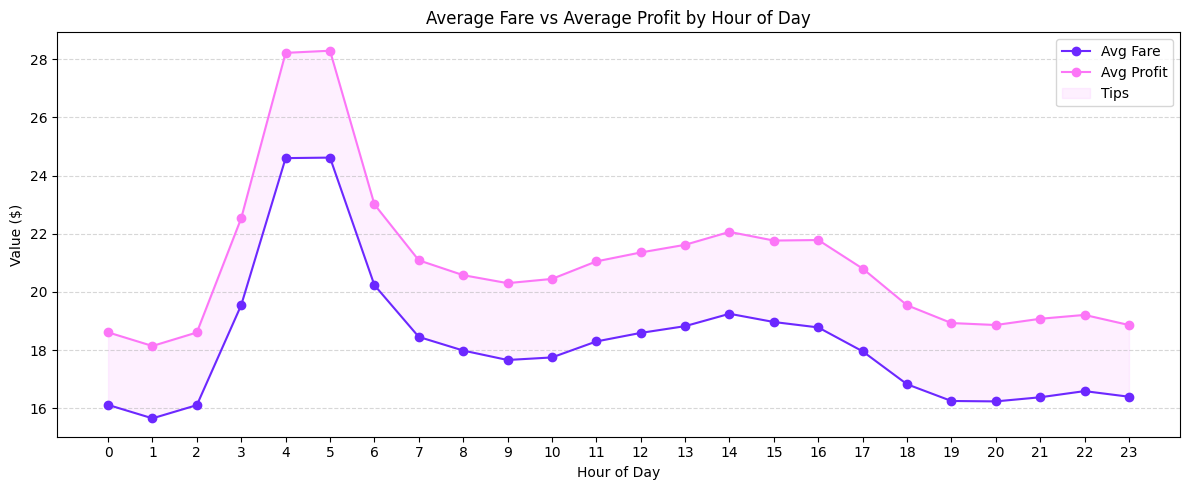

In [30]:
pretty_palette = ['#6c28ff','#fc76f7', "#fab4ff"]

hourly_avg_fare = hourly.groupby("hour")["avg_fare"].mean().reset_index()
hourly_avg_profit = hourly.groupby("hour")["avg_profit"].mean().reset_index()

plt.figure(figsize=(12,5))

plt.plot(hourly_avg_fare["hour"], hourly_avg_fare["avg_fare"], marker="o", label="Avg Fare", color="#6c28ff")
plt.plot(hourly_avg_profit["hour"], hourly_avg_profit["avg_profit"], marker="o", label="Avg Profit", color="#fc76f7")

# Shade between two lines
plt.fill_between(
    hourly_avg_fare["hour"],
    hourly_avg_fare["avg_fare"],
    hourly_avg_profit["avg_profit"],
    color=pretty_palette[2],
    alpha=0.2,
    label="Tips"
)

plt.title("Average Fare vs Average Profit by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Value ($)")
plt.xticks(range(0,24))
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

## 8. Train/Test Split — Temporal Holdout

A critical methodological consideration for time-series data is the **split
strategy**.

**Why not random split?**  
A random train/test split would constitute **data leakage** — the model would be
trained on data from the future and tested on the past, producing overly optimistic
and unrealistic evaluation metrics.

**Temporal holdout approach:**  
We train on **January–October 2024** and evaluate on **November–December 2024**.  
This mirrors the real-world scenario where a model trained on historical data is
deployed to predict future demand.

The same split date is used across all models (XGBoost, Random Forest, Neural
Network) to ensure fair and consistent comparisons.

In [1]:
# Temporal split: train on Jan-Oct, test on Nov-Dec
# This prevents data leakage — we never train on future data
split_date = "2024-11-01"

train = hourly[hourly["pickup_hour"] < split_date]
test  = hourly[hourly["pickup_hour"] >= split_date]

# Define the feature set (inputs) and target variable (output) - DEMAND
features_demand = [
    "hour",            # time of day (0-23)
    "day_of_week",     # day of week (0=Monday, 6=Sunday)
    "month",           # month of year (1-12)
    "is_weekend",      # weekend flag (1=Sat/Sun, 0=weekday)
    "PULocationID",    # which Manhattan zone (1-263)
    "demand_lag_1h",   # rides in this zone 1 hour ago
    "demand_lag_24h",  # rides in this zone 24 hours ago
    "demand_lag_168h"  # rides in this zone 1 week ago
]

# Define the feature set (inputs) and target variable (output) - FARE
features_fare = [
    "hour",            # time of day (0-23)
    "day_of_week",     # day of week (0=Monday, 6=Sunday)
    "month",           # month of year (1-12)
    "is_weekend",      # weekend flag (1=Sat/Sun, 0=weekday)
    "PULocationID",    # which Manhattan zone (1-263)
    "demand_lag_1h",   # rides in this zone 1 hour ago
    # "avg_fare_lag_1h",   # avg fare in this zone 1 hour ago
    "avg_fare_lag_24h"   # avg fare in this zone 24 hours ago
]

target_demand = "demand"  # our prediction target: number of rides per zone per hour
target_fare = "avg_fare"  # our prediction target: average fare per ride in that zone/hour

X_train = train[features_fare]
y_train = train[target_fare]
X_test  = test[features_fare]
y_test  = test[target_fare]

print(f"Training rows:  {len(X_train):,}")
print(f"Test rows:      {len(X_test):,}")
print(f"\nTraining period: {train['pickup_hour'].min()} → {train['pickup_hour'].max()}")
print(f"Test period:     {test['pickup_hour'].min()} → {test['pickup_hour'].max()}")

NameError: name 'hourly' is not defined

## 9. Model Training — XGBoost Regressor

We train an **XGBoost (Extreme Gradient Boosting)** regressor as our primary model.
XGBoost is an ensemble method that builds decision trees **sequentially**, with each
tree correcting the residual errors of its predecessor through gradient descent.

**Why XGBoost?**
- Consistently achieves state-of-the-art performance on structured/tabular data
- Handles mixed feature types (numeric + categorical zone IDs) natively
- Provides built-in feature importance scores for interpretability
- Computationally efficient with large datasets

**Key hyperparameters:**
| Parameter | Value | Purpose |
|---|---|---|
| `n_estimators` | 300 | Number of boosting rounds (trees) |
| `learning_rate` | 0.05 | Shrinkage factor — reduces overfitting |
| `max_depth` | 6 | Maximum tree depth — controls complexity |
| `random_state` | 42 | Ensures reproducibility |

In [16]:
# Initialise XGBoost regressor with chosen hyperparameters
model = XGBRegressor(
    n_estimators  = 300,   # build 300 trees sequentially
    learning_rate = 0.05,  # conservative learning rate to avoid overfitting
    max_depth     = 6,     # moderate tree depth
    random_state  = 42     # fixed seed for reproducibility
)

print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Training complete!")

Training XGBoost model...
Training complete!


## 10. Model Evaluation

We evaluate model performance using two standard regression metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | Mean Absolute Error | Average absolute difference — directly interpretable in ride counts |
| **RMSE** | Root Mean Squared Error | Penalises large errors more heavily than MAE |

A substantially higher RMSE relative to MAE indicates the model struggles with
**peak demand periods** (e.g. New Year's Eve, rush hours in busy zones).

Both metrics are reported in the **original units** (rides per hour per zone),
making them interpretable to a non-technical Operations Manager.

In [18]:
# Generate predictions on the held-out test set
predictions = model.predict(X_test)

# Calculate evaluation metrics
mae  = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("=== XGBoost Fare Model — Evaluation Results ===")
print(f"MAE  (Mean Absolute Error):  £{mae:.2f} per trip")
print(f"RMSE (Root Mean Sq. Error):  £{rmse:.2f} per trip")
print()
print(f"Interpretation: On average, our fare predictions are")
print(f"off by approximately £{mae:.2f} per trip.")

=== XGBoost Fare Model — Evaluation Results ===
MAE  (Mean Absolute Error):  £3.44 per trip
RMSE (Root Mean Sq. Error):  £7.02 per trip

Interpretation: On average, our fare predictions are
off by approximately £3.44 per trip.


## 11. Feature Importance Analysis

One of the key advantages of tree-based models is the ability to quantify the
**relative contribution of each feature** to the model's predictions. XGBoost
computes importance scores based on the frequency and magnitude of feature use
across all 300 trees.

This analysis directly answers the business question:
> *"What drives the average taxi fare in Manhattan?"*

The results provide actionable insights for the Operations Manager — for example,
if lag features dominate, it suggests drivers should respond to **real-time demand and fare
signals** rather than following a fixed schedule.

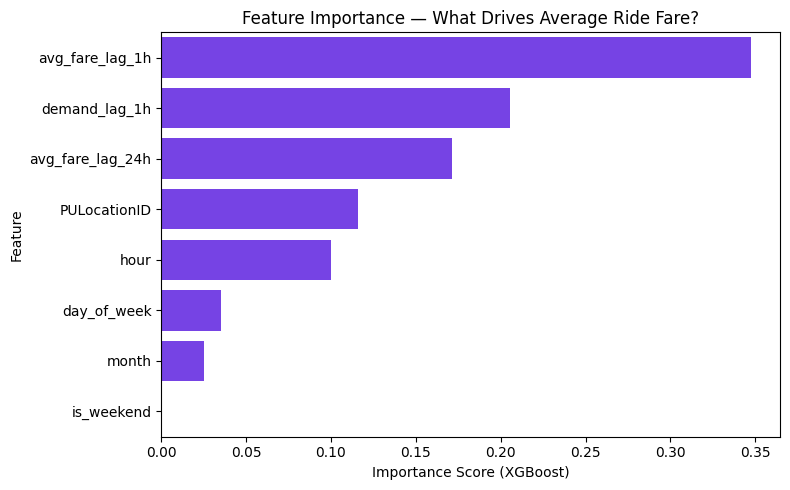


Feature Importance Rankings:
         feature  importance
 avg_fare_lag_1h    0.347227
   demand_lag_1h    0.205443
avg_fare_lag_24h    0.171165
    PULocationID    0.115725
            hour    0.099930
     day_of_week    0.035140
           month    0.025370
      is_weekend    0.000000


In [20]:
# Extract and sort feature importance scores
importance = pd.DataFrame({
    "feature":    features_fare,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# Visualise as horizontal bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="importance", y="feature", color=pretty_palette[0])
plt.title("Feature Importance — What Drives Average Ride Fare?")
plt.xlabel("Importance Score (XGBoost)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Print the raw importance table
print("\nFeature Importance Rankings:")
print(importance.to_string(index=False))

## More In-Depth EDA

### 1. Weather Trends

### 2. Time of Day Trends

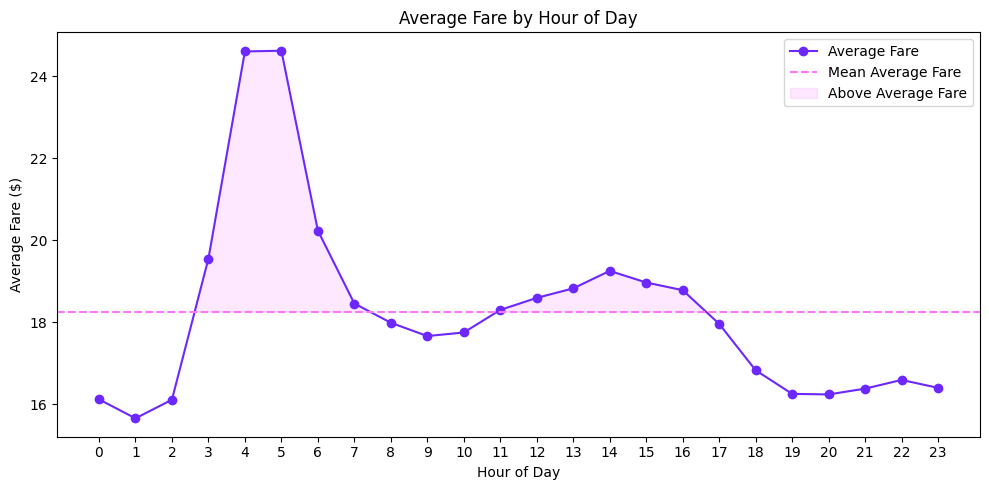

In [35]:
# Group by hour of day
fare_by_hour = hourly.groupby("hour")["avg_fare"].mean().reset_index()

# Compute overall average
avg_fare_overall = fare_by_hour["avg_fare"].mean()

# Plot
plt.figure(figsize=(10, 5))

x = fare_by_hour["hour"]
y = fare_by_hour["avg_fare"]

plt.plot(x, y, marker="o", label="Average Fare", color=pretty_palette[0])

# Mean line
plt.axhline(y=avg_fare_overall, linestyle="--", label="Mean Average Fare", color=pretty_palette[1])

# Highlight areas where fare > average
plt.fill_between(
    x,
    y,
    avg_fare_overall,
    where=(y > avg_fare_overall),
    alpha=0.3,
    interpolate=True,
    label="Above Average Fare",
    color=pretty_palette[2]
)

plt.title("Average Fare by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Fare ($)")
plt.xticks(range(0, 24))
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# Optional: time of day label (useful for report visualisations)
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 10:
        return "Morning Rush"
    elif 10 <= hour < 16:
        return "Midday"
    elif 16 <= hour < 20:
        return "Evening Rush"
    else:
        return "Evening"

hourly["time_of_day"] = hourly["hour"].apply(get_time_of_day)

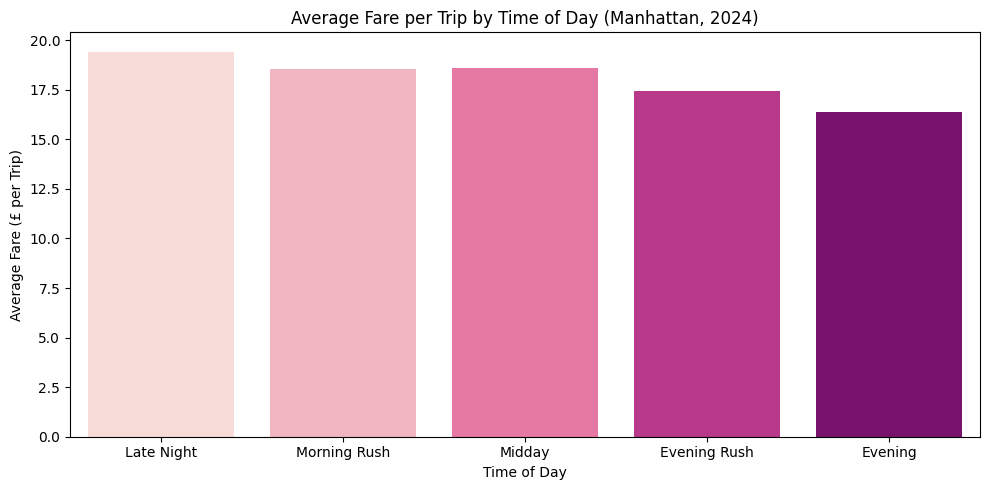

 time_of_day  avg_fare
  Late Night 19.426299
Morning Rush 18.565786
      Midday 18.615392
Evening Rush 17.458632
     Evening 16.401068


In [24]:
# Average fare per zone grouped by time of day
# This shows how pricing varies across different periods

time_of_day_fare = hourly.groupby("time_of_day")["avg_fare"].mean().reset_index()

# Define order for logical display
time_order = ["Late Night", "Morning Rush", "Midday", "Evening Rush", "Evening"]
time_of_day_fare["time_of_day"] = pd.Categorical(
    time_of_day_fare["time_of_day"], categories=time_order, ordered=True
)
time_of_day_fare = time_of_day_fare.sort_values("time_of_day")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=time_of_day_fare,
    x="time_of_day",
    y="avg_fare",
    hue="time_of_day",
    palette="RdPu",
    legend=False
)

plt.title("Average Fare per Trip by Time of Day (Manhattan, 2024)")
plt.xlabel("Time of Day")
plt.ylabel("Average Fare (£ per Trip)")

plt.tight_layout()
plt.show()

print(time_of_day_fare.to_string(index=False))

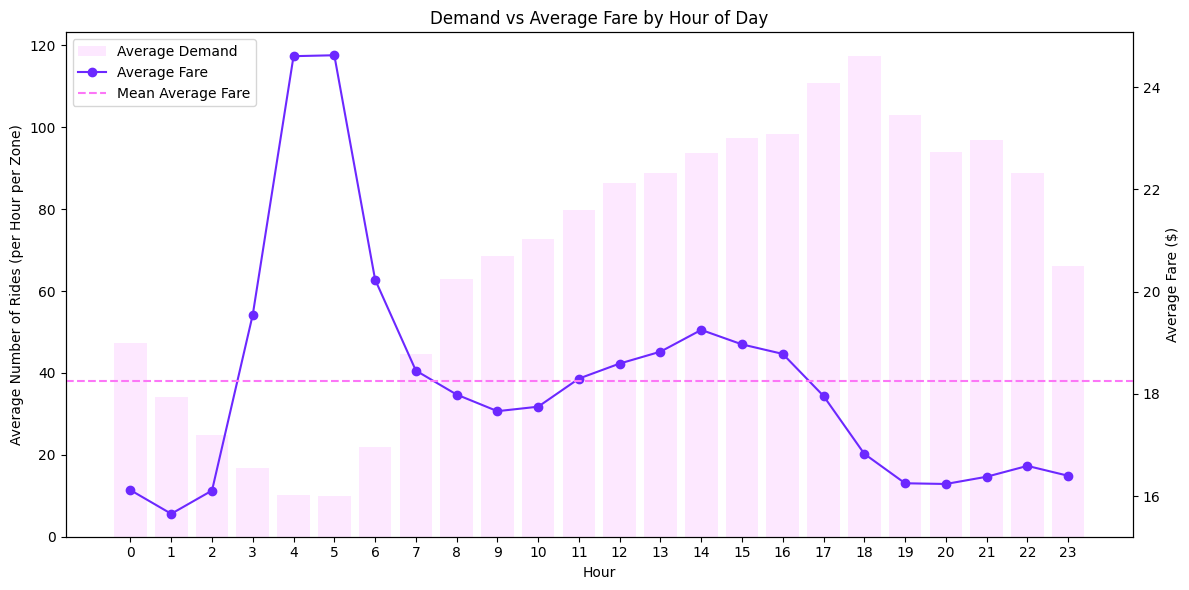

In [44]:
# Average demand and average fare by hour
hourly_summary = hourly.groupby("hour").agg(
    avg_demand=("demand", "mean"),
    avg_fare=("avg_fare", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: average demand by hour
ax1.bar(
    hourly_summary["hour"],
    hourly_summary["avg_demand"],
    alpha=0.3,
    label="Average Demand",
    color=pretty_palette[2]
)
ax1.set_xlabel("Hour")
ax1.set_ylabel("Average Number of Rides (per Hour per Zone)")
ax1.set_xticks(range(24))

# Line chart: average fare by hour
ax2 = ax1.twinx()
ax2.plot(
    hourly_summary["hour"],
    hourly_summary["avg_fare"],
    marker="o",
    label="Average Fare",
    color=pretty_palette[0]
)
ax2.set_ylabel("Average Fare ($)")

# Mean line
plt.axhline(y=avg_fare_overall, linestyle="--", label="Mean Average Fare", color=pretty_palette[1])

plt.title("Demand vs Average Fare by Hour of Day")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

- Look at tips for 3am-6am to provide incentive for drivers between those times?

### 3. Monthly Trends

In [ ]:
# Mapping month numbers to names for readability
import calendar

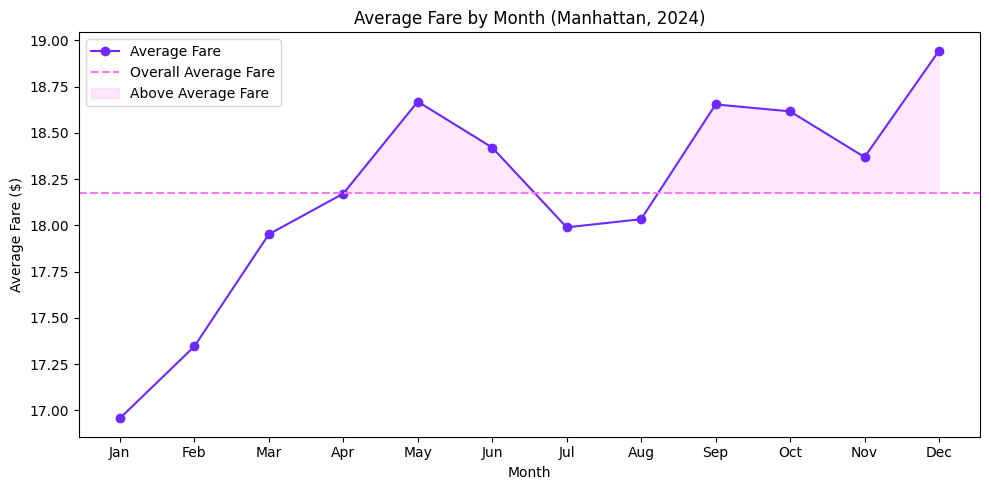

In [61]:
monthly_fare = hourly.groupby("month")["avg_fare"].mean().reset_index()
monthly_fare["month_name"] = monthly_fare["month"].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_fare["month_name"],
    monthly_fare["avg_fare"],
    marker="o",
    label="Average Fare",
    color=pretty_palette[0]
)

avg_fare_overall = monthly_fare["avg_fare"].mean()

plt.axhline(
    y=avg_fare_overall,
    linestyle="--",
    label="Overall Average Fare",
    color=pretty_palette[1]
)

plt.fill_between(
    monthly_fare["month_name"],
    monthly_fare["avg_fare"],
    avg_fare_overall,
    where=(monthly_fare["avg_fare"] > avg_fare_overall),
    alpha=0.3,
    interpolate=True,
    label="Above Average Fare",
    color=pretty_palette[2]
)

plt.title("Average Fare by Month (Manhattan, 2024)")
plt.xlabel("Month")
plt.ylabel("Average Fare ($)")
plt.legend()

plt.tight_layout()
plt.show()

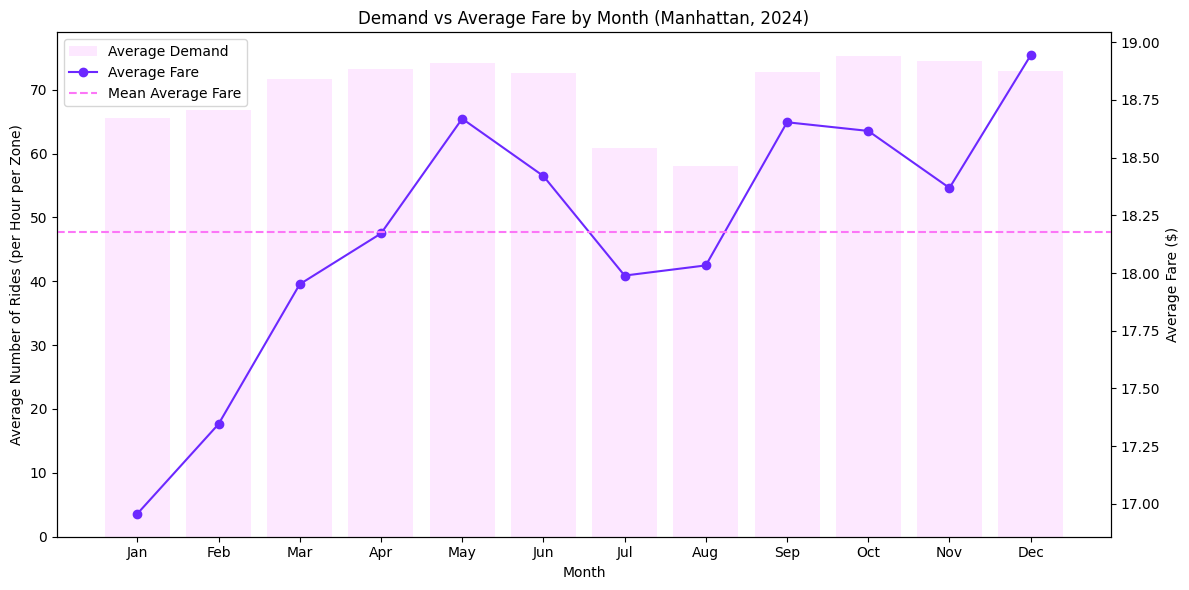

In [62]:
# Average demand and average fare by month
monthly_summary = hourly.groupby("month").agg(
    avg_demand=("demand", "mean"),
    avg_fare=("avg_fare", "mean")
).reset_index()

monthly_summary["month_name"] = monthly_summary["month"].apply(lambda x: calendar.month_abbr[x])

monthly_summary["month_name"] = pd.Categorical(
    monthly_summary["month_name"],
    categories=list(calendar.month_abbr)[1:],  # Jan–Dec
    ordered=True
)
monthly_summary = monthly_summary.sort_values("month_name")

avg_fare_overall = monthly_summary["avg_fare"].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    monthly_summary["month_name"],
    monthly_summary["avg_demand"],
    alpha=0.3,
    label="Average Demand",
    color=pretty_palette[2]
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Average Number of Rides (per Hour per Zone)")

ax2 = ax1.twinx()
ax2.plot(
    monthly_summary["month_name"],
    monthly_summary["avg_fare"],
    marker="o",
    label="Average Fare",
    color=pretty_palette[0]
)
ax2.set_ylabel("Average Fare ($)")

ax2.axhline(
    y=avg_fare_overall,
    linestyle="--",
    label="Mean Average Fare",
    color=pretty_palette[1]
)

plt.title("Demand vs Average Fare by Month (Manhattan, 2024)")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

- There appears to be a weak correlation between demand and fare: when demand increases from Jan -> May, so does the average fare
- When demand decreases from Jun -> Aug (summer holidays, people abroad?), average fare decreases
- Average fare decreases in November even though demand is high (maybe we could put our prices up here)
- Fare skyrockets in December even though demand is comparatively slightly less than Oct/Nov (probably because Christmas holidays)
- Highest demand is Winter season Oct/Nov/Dec - bad weather & not many people on holiday?

### 4. Pickup zones, drop-off zones and routes

Looking at top 15 bc cba with all 69 (lol)
- Pickup location rn bc zones hasn't been done and DO isn't included

In [12]:
zone_summary = hourly.groupby("PULocationID").agg(
    avg_demand=("demand", "mean"),
    avg_fare=("avg_fare", "mean")
).reset_index()

# Pick top 15
zone_summary = zone_summary.sort_values("avg_demand", ascending=False).head(15)

# Names instead of numbers
zone_summary = zone_summary.merge(
    zones[["LocationID", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

fig, ax1 = plt.subplots(figsize=(18, 6))

ax1.bar(
    zone_summary["Zone"],
    zone_summary["avg_demand"],
    alpha=0.3,
    label="Average Demand",
    color=pretty_palette[2]
)
ax1.set_xlabel("Zone")
ax1.set_ylabel("Average Rides per Hour per Zone")

ax2 = ax1.twinx()
ax2.plot(
    zone_summary["Zone"],
    zone_summary["avg_fare"],
    marker="o",
    label="Average Fare",
    color=pretty_palette[0]
)
ax2.set_ylabel("Average Fare ($)")

avg_fare_overall = zone_summary["avg_fare"].mean()
ax2.axhline(
    y=avg_fare_overall,
    linestyle="--",
    label="Mean Average Fare",
    color=pretty_palette[1] # This should be purple!!!
)

plt.title("Demand vs Average Fare by Pickup Zone (Top 15 by Demand)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Clunky
zone_summary["Zone_short"] = zone_summary["Zone"].str.replace(" ", "\n")
ax1.set_xticks(range(len(zone_summary)))
ax1.set_xticklabels(zone_summary["Zone_short"])
plt.tight_layout()
plt.show()

NameError: name 'hourly' is not defined